# Stochastic Process - Standalone Walkthrough
## Requirements

```bash
pip install numpy matplotlib yfinance
```

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf

plt.style.use("seaborn-v0_8")

## 1) One sequence: mean and autocorrelation

$$
\mu_X = \frac{1}{N} \sum_{i=0}^{N-1} X_i
$$

$$
R_{XX}(k) = \frac{1}{N} \sum_{i=0}^{N-1+k} X_{i+k}X_i,\quad k=-(N-1),\ldots,(N-1)
$$

Sequence: [ 1. -2.  4.  2.]
Mean: 1.25
Autocorrelation: [ 0.5   0.   -0.5   6.25 -0.5   0.    0.5 ]


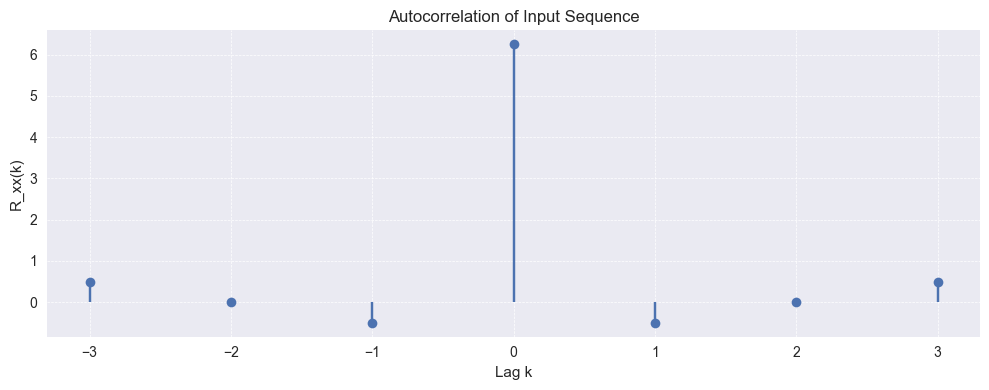

In [2]:
def mean_and_autocorrelation_full_lag(x):
    x_array = np.asarray(x, dtype=float)
    n_samples = x_array.size
    lags = np.arange(-(n_samples - 1), n_samples)
    # np.correlate with mode="full" computes sum(X_{i+k} * X_i); divide by N
    values = np.correlate(x_array, x_array, mode="full") / n_samples
    return float(np.mean(x_array)), lags, values

# Example from Stochastic_Process.md: {X} = {1, -2, 4, 2}
sequence = np.array([1.0, -2.0, 4.0, 2.0])
mean_value, lags, autocorr = mean_and_autocorrelation_full_lag(sequence)

print("Sequence:", sequence)
print("Mean:", mean_value)
print("Autocorrelation:", np.array2string(autocorr, precision=4))

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(lags, autocorr, basefmt=" ")
ax.set(title="Autocorrelation of Input Sequence", xlabel="Lag k", ylabel="R_xx(k)")
ax.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

## 2) Two sequences: autocorrelation and cross-correlation

$$
R_{XY}(k) = \frac{1}{N} \sum_{i=0}^{N-1+k} X_{i+k}Y_i,\quad k=-(N-1),\ldots,(N-1)
$$

X: [ 1. -2.  4.  2.]
Y: [-2.  3.  1.  5.]
R_xx: [ 0.5   0.   -0.5   6.25 -0.5   0.    0.5 ]
R_yy: [-2.5   3.25  0.5   9.75  0.5   3.25 -2.5 ]
R_xy: [ 1.25 -2.25  5.25  1.5   4.5  -0.5  -1.  ]


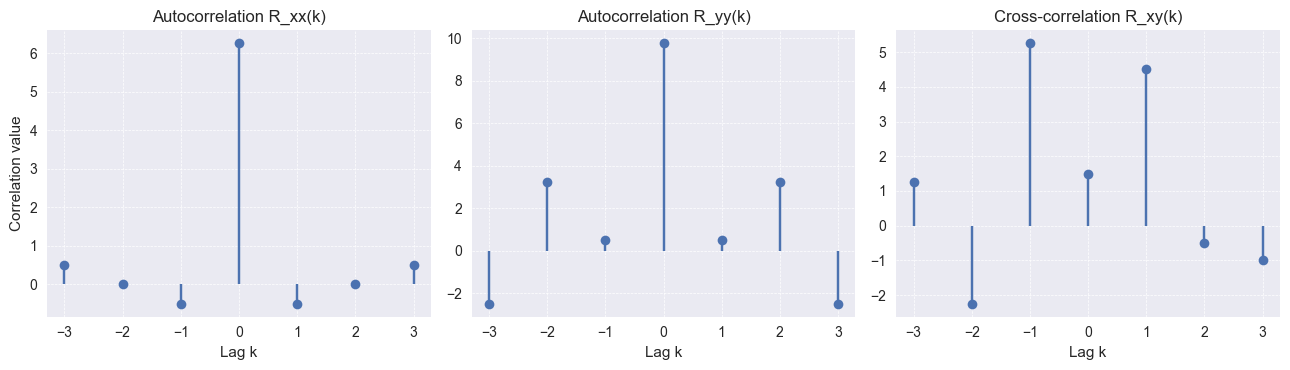

In [3]:
def autocorrelation_full_lag(x):
    x_array = np.asarray(x, dtype=float)
    n_samples = x_array.size
    lags = np.arange(-(n_samples - 1), n_samples)
    # R_XX(k): full-lag autocorrelation, normalized by N
    values = np.correlate(x_array, x_array, mode="full") / n_samples
    return lags, values

def cross_correlation_full_lag(x, y):
    x_array = np.asarray(x, dtype=float)
    y_array = np.asarray(y, dtype=float)
    n_samples = x_array.size
    lags = np.arange(-(n_samples - 1), n_samples)
    # R_XY(k): full-lag cross-correlation, normalized by N
    values = np.correlate(x_array, y_array, mode="full") / n_samples
    return lags, values

# Example from Stochastic_Process.md: {X} = {1, -2, 4, 2}, {Y} = {-2, 3, 1, 5}
x = np.array([1.0, -2.0, 4.0, 2.0])
y = np.array([-2.0, 3.0, 1.0, 5.0])
lags, r_xx = autocorrelation_full_lag(x)
_, r_yy = autocorrelation_full_lag(y)
_, r_xy = cross_correlation_full_lag(x, y)

print("X:", x)
print("Y:", y)
print("R_xx:", np.array2string(r_xx, precision=4))
print("R_yy:", np.array2string(r_yy, precision=4))
print("R_xy:", np.array2string(r_xy, precision=4))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True)
axes[0].stem(lags, r_xx, basefmt=" ")
axes[0].set_title("Autocorrelation R_xx(k)")
axes[1].stem(lags, r_yy, basefmt=" ")
axes[1].set_title("Autocorrelation R_yy(k)")
axes[2].stem(lags, r_xy, basefmt=" ")
axes[2].set_title("Cross-correlation R_xy(k)")
for ax in axes:
    ax.set_xlabel("Lag k")
    ax.grid(True, linestyle="--", linewidth=0.5)
axes[0].set_ylabel("Correlation value")
plt.tight_layout()
plt.show()

## 3) Weakly correlated US stocks A and B (2025)

Log-return convention:

$$
r_t = \log\left(\frac{S_t}{S_{t-1}}\right)
$$

A=XOM, B=JNJ
2025 return samples: 249
Corr(A,B): 0.1811


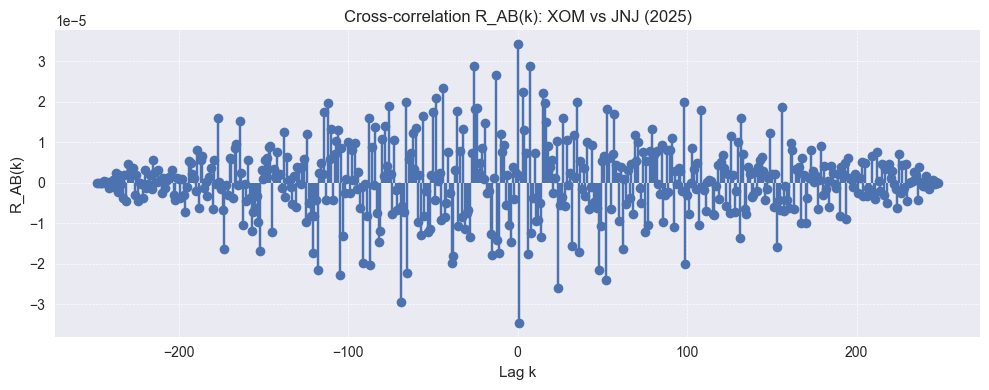

In [4]:
def fetch_2025_log_returns(tickers):
    close = yf.download(
        tickers,
        start="2025-01-01",
        end="2026-01-01",
        auto_adjust=True,
        progress=False,
    )["Close"]
    # Log return: r_t = log(S_t / S_{t-1})
    return np.log(close / close.shift(1)).dropna()

# Weakly correlated pair: XOM (Energy) vs JNJ (Healthcare)
a_ticker = "XOM"
b_ticker = "JNJ"
returns_ab = fetch_2025_log_returns([a_ticker, b_ticker])
x_ab = returns_ab[a_ticker].to_numpy(float)
y_ab = returns_ab[b_ticker].to_numpy(float)
lags_ab, r_ab = cross_correlation_full_lag(x_ab, y_ab)

print(f"A={a_ticker}, B={b_ticker}")
print(f"2025 return samples: {x_ab.size}")
print(f"Corr(A,B): {np.corrcoef(x_ab, y_ab)[0, 1]:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(lags_ab, r_ab, basefmt=" ")
ax.set(title=f"Cross-correlation R_AB(k): {a_ticker} vs {b_ticker} (2025)", xlabel="Lag k", ylabel="R_AB(k)")
ax.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

## 4) Strongly correlated US stocks C and D (2025)

C=AAPL, D=MSFT
2025 return samples: 249
Corr(C,D): 0.4774


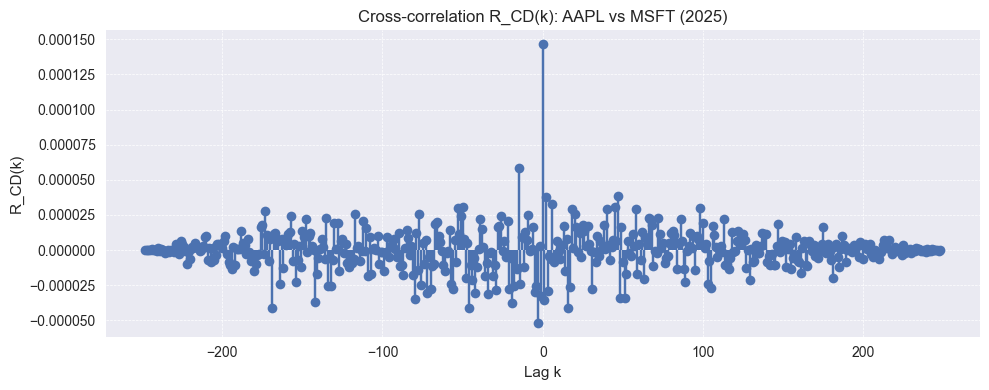

In [5]:
# Strongly correlated pair: AAPL vs MSFT (both large-cap tech)
c_ticker = "AAPL"
d_ticker = "MSFT"
returns_cd = fetch_2025_log_returns([c_ticker, d_ticker])
x_cd = returns_cd[c_ticker].to_numpy(float)
y_cd = returns_cd[d_ticker].to_numpy(float)
lags_cd, r_cd = cross_correlation_full_lag(x_cd, y_cd)

print(f"C={c_ticker}, D={d_ticker}")
print(f"2025 return samples: {x_cd.size}")
print(f"Corr(C,D): {np.corrcoef(x_cd, y_cd)[0, 1]:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(lags_cd, r_cd, basefmt=" ")
ax.set(title=f"Cross-correlation R_CD(k): {c_ticker} vs {d_ticker} (2025)", xlabel="Lag k", ylabel="R_CD(k)")
ax.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

## 5) Covariance matrix of A, B, C, D (2025)

$$
\Sigma = \frac{1}{N}(X-\bar{X})^\top(X-\bar{X})
$$

Tickers: ['XOM', 'JNJ', 'AAPL', 'MSFT']
Covariance matrix (2025 log returns):
[[ 2.20108757e-04  3.31860838e-05  1.15392658e-04  4.04736965e-05]
 [ 3.31860838e-05  1.52505053e-04  2.21339581e-05 -3.20428293e-05]
 [ 1.15392658e-04  2.21339581e-05  4.08859906e-04  1.46069239e-04]
 [ 4.04736965e-05 -3.20428293e-05  1.46069239e-04  2.28994095e-04]]
A = XOM
B = JNJ
C = AAPL
D = MSFT


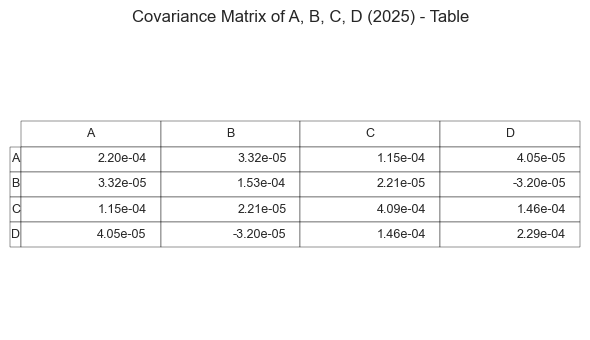

In [6]:
def covariance_matrix(data):
    data_array = np.asarray(data, dtype=float)
    centered = data_array - np.mean(data_array, axis=0)
    n_samples = data_array.shape[0]
    # Sigma = (1/N) * (X - X_bar)^T @ (X - X_bar)
    return (centered.T @ centered) / n_samples

tickers = [a_ticker, b_ticker, c_ticker, d_ticker]
returns_all = fetch_2025_log_returns(tickers)
matrix = returns_all[tickers].to_numpy(float)
cov = covariance_matrix(matrix)

print("Tickers:", tickers)
print("Covariance matrix (2025 log returns):")
print(np.array2string(cov, precision=8))
for i, ticker in enumerate(tickers):
    print(f"{['A', 'B', 'C', 'D'][i]} = {ticker}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.axis("off")
cov_text = [[f"{value:.2e}" for value in row] for row in cov]
table = ax.table(
    cellText=cov_text,
    rowLabels=["A", "B", "C", "D"],
    colLabels=["A", "B", "C", "D"],
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.4)
ax.set_title("Covariance Matrix of A, B, C, D (2025) - Table", pad=12)
plt.tight_layout()
plt.show()